In [1]:
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import classification_report

Matplotlib is building the font cache; this may take a moment.


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [4]:
import os

# Set the base path to your Kaggle dataset
BASE_PATH = "/kaggle/input/interior-design-images-and-metadata/Pinterest Interior Design Images and Metadata"

# Walk through all folders and subfolders
for root, dirs, files in os.walk(BASE_PATH):
    print("Folder:", root)
    if dirs:
        print("  Subfolders:", dirs)
    if files:
        print("  Number of files:", len(files))
    print("-" * 50)

Train samples: 2648
Val samples: 663
Test samples: 828
Image opened successfully with size: (236, 354)


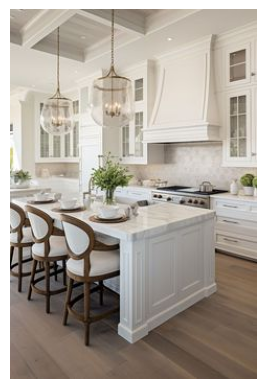

In [14]:
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Corrected paths pointing straight to your local project folder
BASE_PATH = Path("C:/Users/renug/OneDrive/Desktop/AI Interior Final Project")

TRAIN_CSV = BASE_PATH / "train_data.csv"
VAL_CSV   = BASE_PATH / "val_data.csv"
TEST_CSV  = BASE_PATH / "test_data.csv"

# Load CSV files
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Test samples:", len(test_df))

# Adjust image path
train_df['image_path'] = train_df['image_path'].apply(lambda x: '/'.join(x.split('/')[-3:]))
val_df['image_path']   = val_df['image_path'].apply(lambda x: '/'.join(x.split('/')[-3:]))
test_df['image_path']  = test_df['image_path'].apply(lambda x: '/'.join(x.split('/')[-3:]))

img_path = BASE_PATH / train_df['image_path'].iloc[0]
img = Image.open(img_path).convert("RGB")
print("Image opened successfully with size:", img.size)

plt.imshow(img)
plt.axis('off')
plt.show()


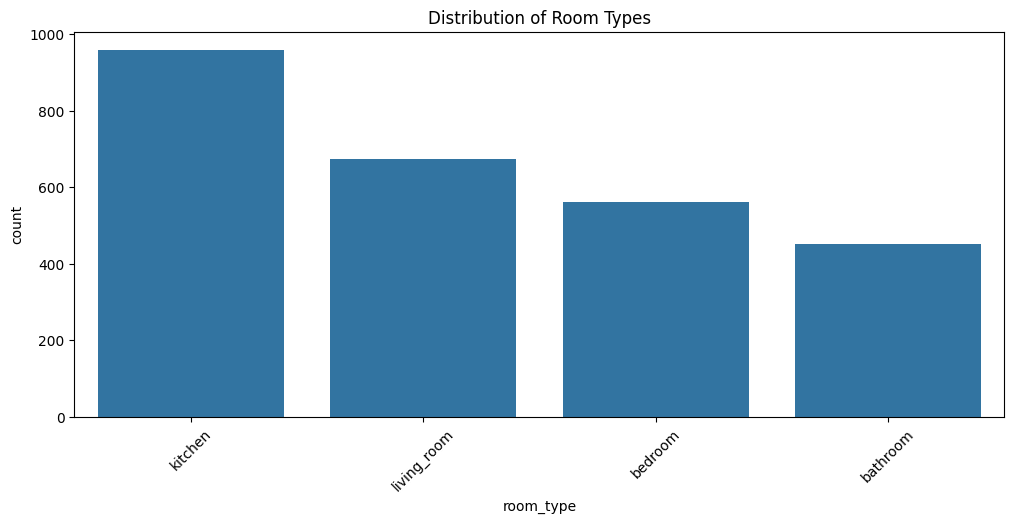

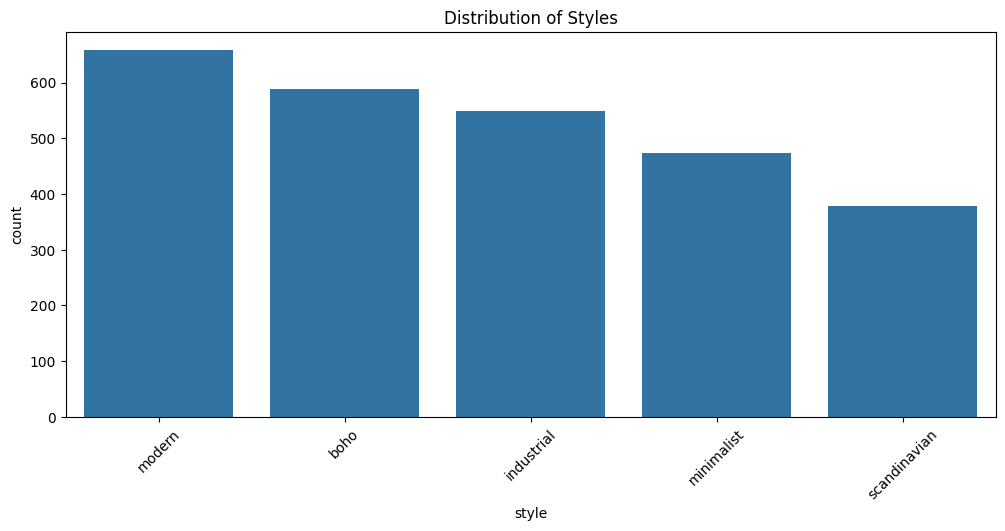

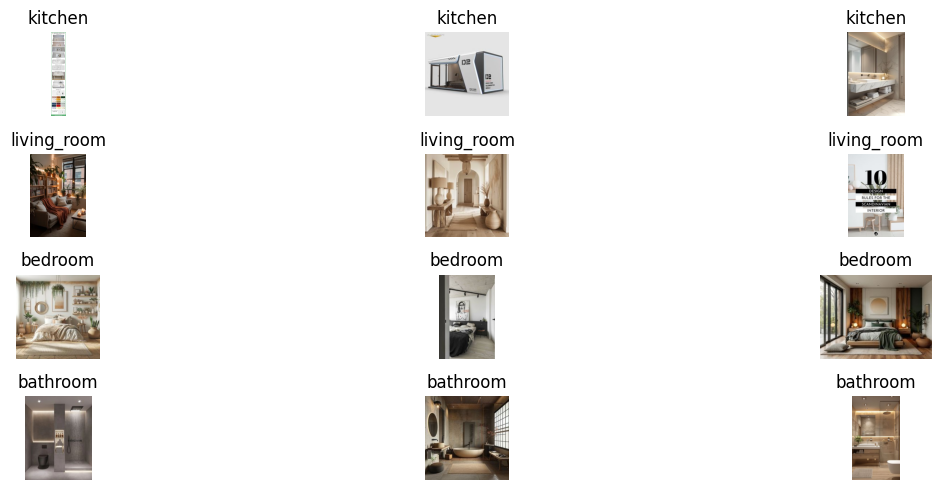

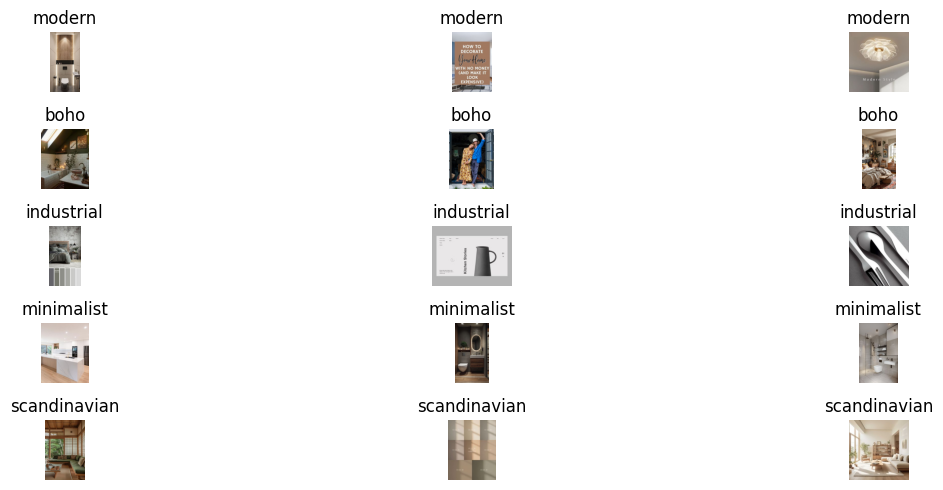

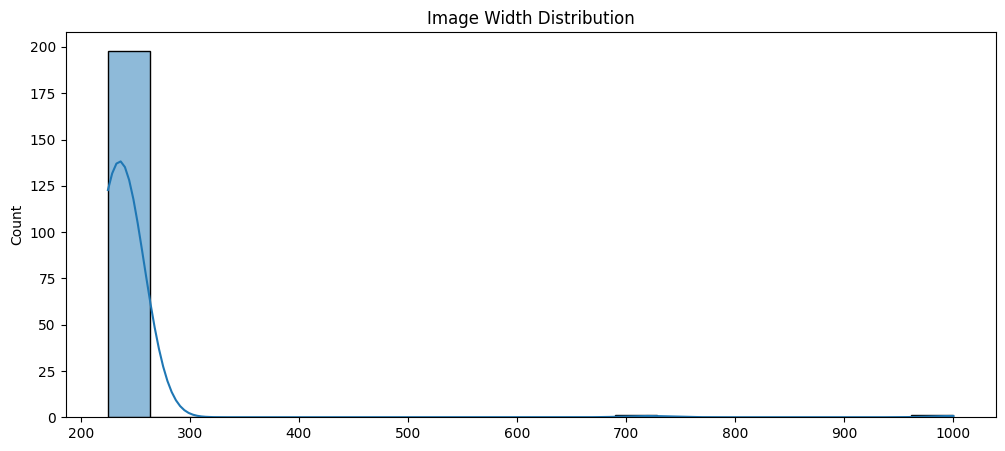

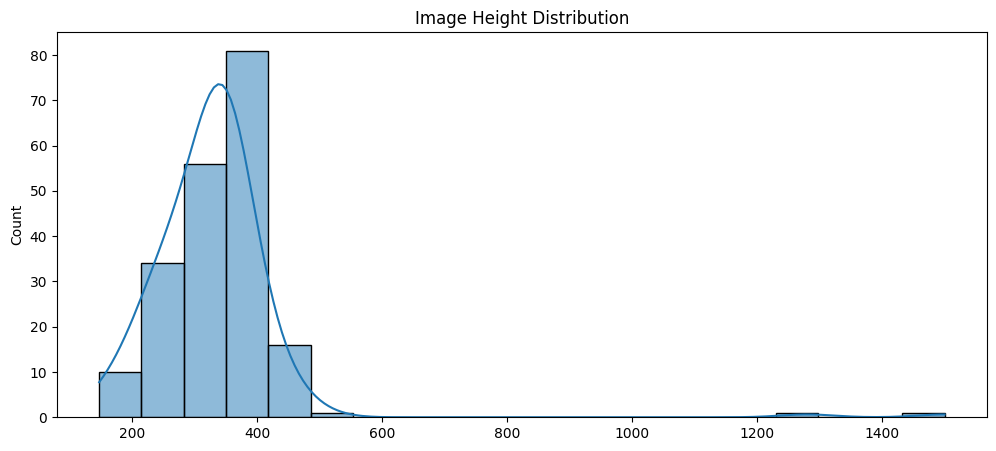

Image size stats (sampled 200 images):
Width - mean: 242.0, min: 225, max: 1000
Height - mean: 330.2, min: 147, max: 1500


In [16]:
import seaborn as sns
import numpy as np

# Distribution per category
plt.figure(figsize=(12,5))
sns.countplot(data=train_df, x='room_type', order=train_df['room_type'].value_counts().index)
plt.title("Distribution of Room Types")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(data=train_df, x='style', order=train_df['style'].value_counts().index)
plt.title("Distribution of Styles")
plt.xticks(rotation=45)
plt.show()


#  SAMPLE IMAGES PER CATEGORY

def show_samples(df, category_col, n_samples=3):
    plt.figure(figsize=(15,5))
    categories = df[category_col].unique()
    for i, cat in enumerate(categories[:5]):  # show first 5 categories
        cat_images = df[df[category_col]==cat]['image_path'].sample(n_samples, random_state=42)
        for j, img_name in enumerate(cat_images):
            img_path = BASE_PATH / img_name
            try:
                img = Image.open(img_path).convert("RGB")
                plt.subplot(len(categories[:5]), n_samples, i*n_samples+j+1)
                plt.imshow(img)
                plt.title(f"{cat}")
                plt.axis('off')
            except FileNotFoundError:
                print("Missing file:", img_path)
    plt.tight_layout()
    plt.show()

show_samples(train_df, 'room_type')
show_samples(train_df, 'style')

# Image size
widths, heights = [], []
for img_name in train_df['image_path'].sample(200, random_state=42):  # sample 200 images for speed
    img_path = BASE_PATH / img_name
    try:
        img = Image.open(img_path)
        widths.append(img.width)
        heights.append(img.height)
    except FileNotFoundError:
        continue

plt.figure(figsize=(12,5))
sns.histplot(widths, bins=20, kde=True)
plt.title("Image Width Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(heights, bins=20, kde=True)
plt.title("Image Height Distribution")
plt.show()

print("Image size stats (sampled 200 images):")
print("Width - mean: {:.1f}, min: {}, max: {}".format(np.mean(widths), np.min(widths), np.max(widths)))
print("Height - mean: {:.1f}, min: {}, max: {}".format(np.mean(heights), np.min(heights), np.max(heights)))


In [18]:
from sklearn.preprocessing import LabelEncoder

# Room type
room_encoder = LabelEncoder()
train_df['room_idx'] = room_encoder.fit_transform(train_df['room_type'])
val_df['room_idx'] = room_encoder.transform(val_df['room_type'])

# Style
style_encoder = LabelEncoder()
train_df['style_idx'] = style_encoder.fit_transform(train_df['style'])
val_df['style_idx'] = style_encoder.transform(val_df['style'])

In [19]:
# Create mappings for room and style labels
room_mapping = {name: idx for idx, name in enumerate(train_df['room_type'].unique())}
style_mapping = {name: idx for idx, name in enumerate(train_df['style'].unique())}

In [20]:
# DATASET CLASS (MULTI-TASK: ROOM + STYLE)
class InteriorDataset(Dataset):
    def __init__(self, df, base_path, transform=None, room_mapping=None, style_mapping=None):
        self.df = df
        self.base_path = base_path
        self.transform = transform

        # Create mappings if not provided
        if room_mapping is None:
            self.room_mapping = {name: idx for idx, name in enumerate(df['room_type'].unique())}
        else:
            self.room_mapping = room_mapping

        if style_mapping is None:
            self.style_mapping = {name: idx for idx, name in enumerate(df['style'].unique())}
        else:
            self.style_mapping = style_mapping

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.base_path / row['image_path']
        image = Image.open(img_path).convert("RGB")

        # Use mapping to convert string labels to integers
        room_label = self.room_mapping[row['room_type']]
        style_label = self.style_mapping[row['style']]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(room_label), torch.tensor(style_label)

In [21]:
#TRANSFORMS 
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

In [22]:

train_dataset = InteriorDataset(train_df, BASE_PATH, transform=train_transform,
                                room_mapping=room_mapping, style_mapping=style_mapping)
val_dataset   = InteriorDataset(val_df, BASE_PATH, transform=val_transform,
                                room_mapping=room_mapping, style_mapping=style_mapping)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [25]:
# Multi task Efficient model
import timm
import torch.nn as nn

class MultiTaskEfficientNet(nn.Module):
    def __init__(self, model_name="tf_efficientnet_b0_ns", freeze=False, num_room_classes=None, num_style_classes=None):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=True)
        if freeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # replace classifier with multi-task heads
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()
        self.room_head  = nn.Linear(in_features, num_room_classes)
        self.style_head = nn.Linear(in_features, num_style_classes)

    def forward(self, x):
        feat = self.backbone(x)
        room_out  = self.room_head(feat)
        style_out = self.style_head(feat)
        return room_out, style_out

num_room_classes  = train_df['room_type'].nunique()
num_style_classes = train_df['style'].nunique()


c:\Users\renug\OneDrive\Desktop\AI Interior Final Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    for epoch in range(epochs):
        model.train()
        running_loss, running_corrects = 0, 0
        total_samples = 0

        for imgs, room_labels, style_labels in train_loader:
            imgs = imgs.to(device)
            room_labels  = room_labels.to(device)
            style_labels = style_labels.to(device)

            optimizer.zero_grad()
            room_out, style_out = model(imgs)
            loss_room  = criterion(room_out, room_labels)
            loss_style = criterion(style_out, style_labels)
            loss = loss_room + loss_style
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            running_corrects += ((room_out.argmax(1)==room_labels).sum().item() +
                                 (style_out.argmax(1)==style_labels).sum().item())
            total_samples += imgs.size(0)*2  # multiply by 2 for room+style

        avg_train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects / total_samples

        # Validation
        model.eval()
        val_loss, val_corrects, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, room_labels, style_labels in val_loader:
                imgs = imgs.to(device)
                room_labels  = room_labels.to(device)
                style_labels = style_labels.to(device)

                room_out, style_out = model(imgs)
                loss = criterion(room_out, room_labels) + criterion(style_out, style_labels)
                val_loss += loss.item() * imgs.size(0)
                val_corrects += ((room_out.argmax(1)==room_labels).sum().item() +
                                 (style_out.argmax(1)==style_labels).sum().item())
                val_total += imgs.size(0)*2

        avg_val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_corrects / val_total

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [ ]:
results = {}
trained_models = {}  # store model objects
model_paths = {}     # store saved model paths

# List of experiments: (model_name, architecture, freeze)
experiments = [
    ('EfficientNetB0 Frozen', 'tf_efficientnet_b0_ns', True),
    ('EfficientNetB0 Fine-tuned', 'tf_efficientnet_b0_ns', False),
    ('EfficientNetB3 Frozen', 'tf_efficientnet_b3_ns', True),
    ('EfficientNetB3 Fine-tuned', 'tf_efficientnet_b3_ns', False)
]

for exp_name, arch, freeze in experiments:
    print(f"\n=== Training {exp_name} ===")
    
    # Initialize model
    model = MultiTaskEfficientNet(
        arch,
        freeze=freeze,
        num_room_classes=num_room_classes,
        num_style_classes=num_style_classes
    )
    
    # Train
    history = train_model(model, train_loader, val_loader, epochs=5)
    
    # Save history
    results[exp_name] = history
    
    # Save model
    model_path = f"{exp_name.replace(' ', '_').lower()}.pth"
    torch.save(model.state_dict(), model_path)
    model_paths[exp_name] = model_path
    
    # Keep model object for immediate use
    trained_models[exp_name] = model

    print(f"Model saved to: {model_path}")



=== Training EfficientNetB0 Frozen ===


c:\Users\renug\OneDrive\Desktop\AI Interior Final Project\.venv\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(
c:\Users\renug\OneDrive\Desktop\AI Interior Final Project\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\renug\.cache\huggingface\hub\models--timm--tf_efficientnet_b0.ns_jft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

def plot_confusion_matrix(model, val_loader, room_mapping, style_mapping, device="cuda"):
    model.to(device)
    model.eval()

    room_inv_map = {v:k for k,v in room_mapping.items()}
    style_inv_map = {v:k for k,v in style_mapping.items()}

    all_room_preds, all_style_preds = [], []
    all_room_labels, all_style_labels = [], []

    with torch.no_grad():
        for imgs, room_labels, style_labels in val_loader:
            imgs = imgs.to(device)
            room_labels = room_labels.to(device)
            style_labels = style_labels.to(device)

            room_out, style_out = model(imgs)
            all_room_preds.extend(room_out.argmax(1).cpu().numpy())
            all_style_preds.extend(style_out.argmax(1).cpu().numpy())
            all_room_labels.extend(room_labels.cpu().numpy())
            all_style_labels.extend(style_labels.cpu().numpy())

    for label_type, y_true, y_pred, inv_map in [("Room", all_room_labels, all_room_preds, room_inv_map),
                                                ("Style", all_style_labels, all_style_preds, style_inv_map)]:
        cm = confusion_matrix(y_true, y_pred)
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        plt.figure(figsize=(6,5))
        sns.heatmap(cm_percent, annot=True, fmt=".1f", xticklabels=[inv_map[i] for i in range(len(inv_map))],
                    yticklabels=[inv_map[i] for i in range(len(inv_map))], cmap="Blues")
        plt.title(f"{label_type} Confusion Matrix ")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.show()


=== Confusion Matrix for EfficientNetB0 Frozen ===


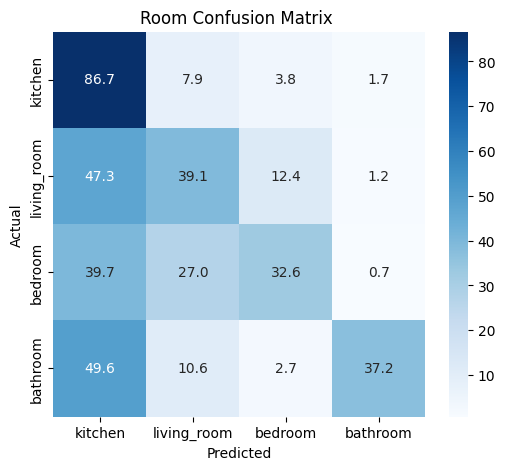

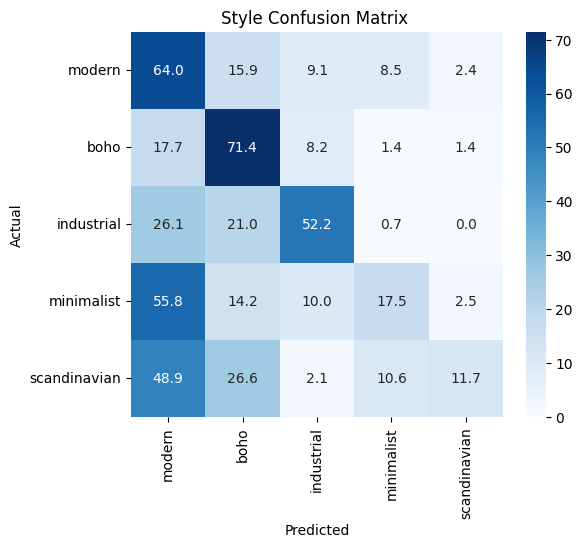


=== Confusion Matrix for EfficientNetB0 Fine-tuned ===


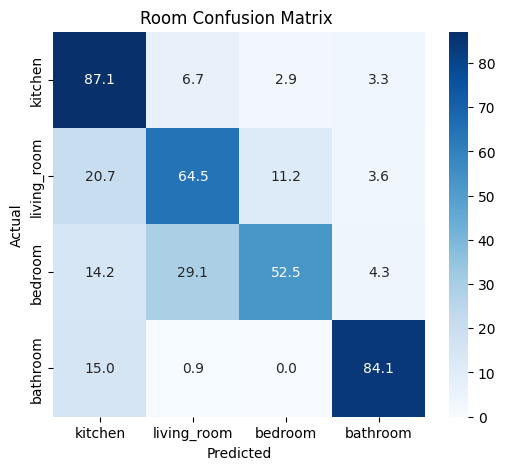

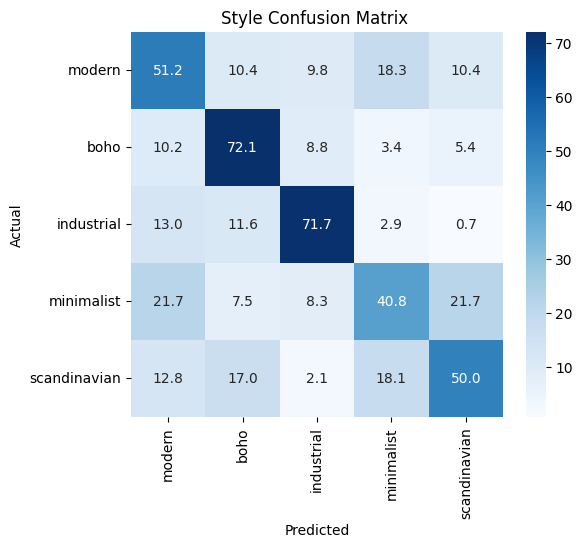


=== Confusion Matrix for EfficientNetB3 Frozen ===


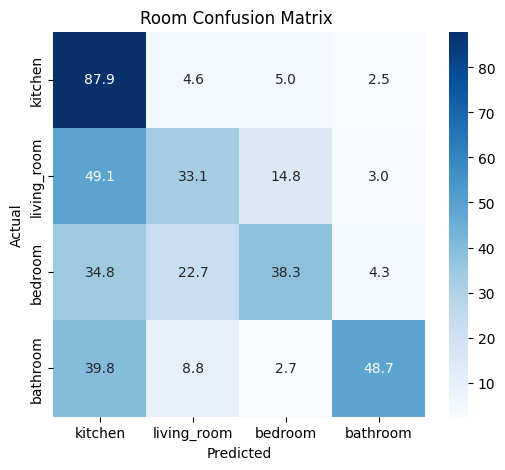

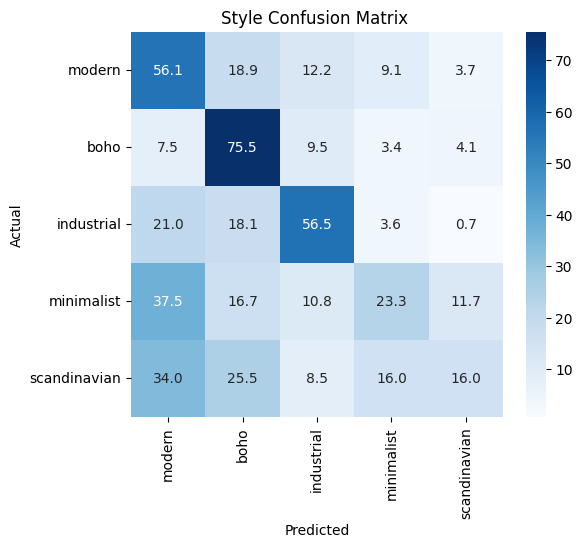


=== Confusion Matrix for EfficientNetB3 Fine-tuned ===


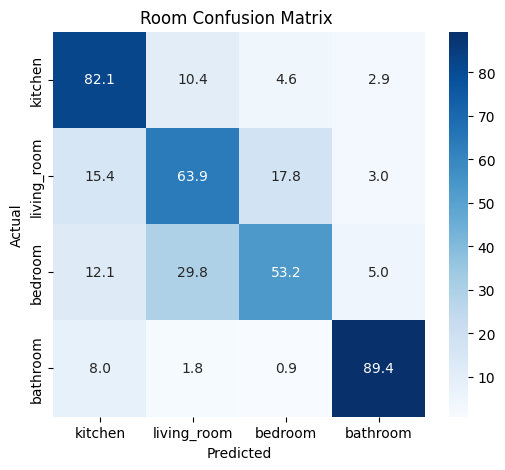

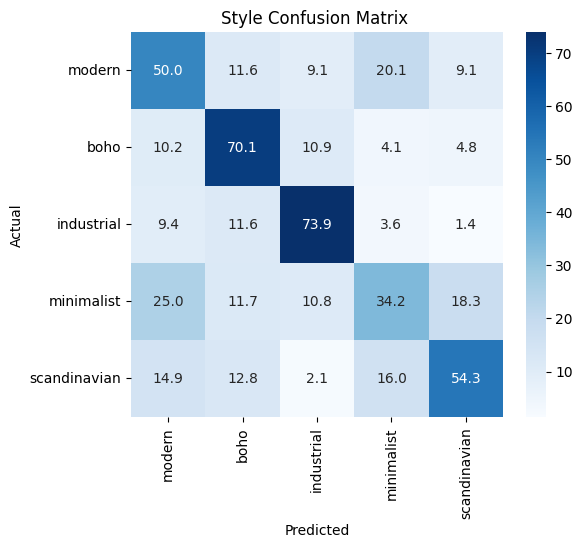

In [ ]:
# Plot confusion matrices for all trained models
for model_name, model in trained_models.items():
    print(f"\n=== Confusion Matrix for {model_name} ===")
    plot_confusion_matrix(model, val_loader, room_mapping, style_mapping)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

def evaluate_model(model, val_loader, device="cuda"):
    model.to(device)
    model.eval()
    all_room_preds, all_style_preds = [], []
    all_room_labels, all_style_labels = [], []

    with torch.no_grad():
        for imgs, room_labels, style_labels in val_loader:
            imgs = imgs.to(device)
            room_labels = room_labels.to(device)
            style_labels = style_labels.to(device)

            room_out, style_out = model(imgs)

            all_room_preds.extend(room_out.argmax(1).cpu().numpy())
            all_style_preds.extend(style_out.argmax(1).cpu().numpy())
            all_room_labels.extend(room_labels.cpu().numpy())
            all_style_labels.extend(style_labels.cpu().numpy())

    room_acc = accuracy_score(all_room_labels, all_room_preds) * 100
    style_acc = accuracy_score(all_style_labels, all_style_preds) * 100
    avg_acc = (room_acc + style_acc) / 2

    print("=== Room Type Metrics ===")
    print(classification_report(all_room_labels, all_room_preds, digits=2))
    print(f"Room Accuracy: {room_acc:.2f}%\n")

    print("=== Style Metrics ===")
    print(classification_report(all_style_labels, all_style_preds, digits=2))
    print(f"Style Accuracy: {style_acc:.2f}%\n")

    print(f"Average Accuracy: {avg_acc:.2f}%\n")

    return room_acc, style_acc, avg_acc

# Evaluate all trained models
for name, model in trained_models.items():
    print(f"=== Evaluating {name} ===")
    evaluate_model(model, val_loader)


=== Evaluating EfficientNetB0 Frozen ===
=== Room Type Metrics ===
              precision    recall  f1-score   support

           0       0.52      0.87      0.65       240
           1       0.49      0.39      0.43       169
           2       0.58      0.33      0.42       141
           3       0.86      0.37      0.52       113

    accuracy                           0.55       663
   macro avg       0.61      0.49      0.51       663
weighted avg       0.58      0.55      0.52       663

Room Accuracy: 54.60%

=== Style Metrics ===
              precision    recall  f1-score   support

           0       0.38      0.64      0.47       164
           1       0.52      0.71      0.60       147
           2       0.64      0.52      0.57       138
           3       0.44      0.17      0.25       120
           4       0.55      0.12      0.19        94

    accuracy                           0.47       663
   macro avg       0.50      0.43      0.42       663
weighted avg       

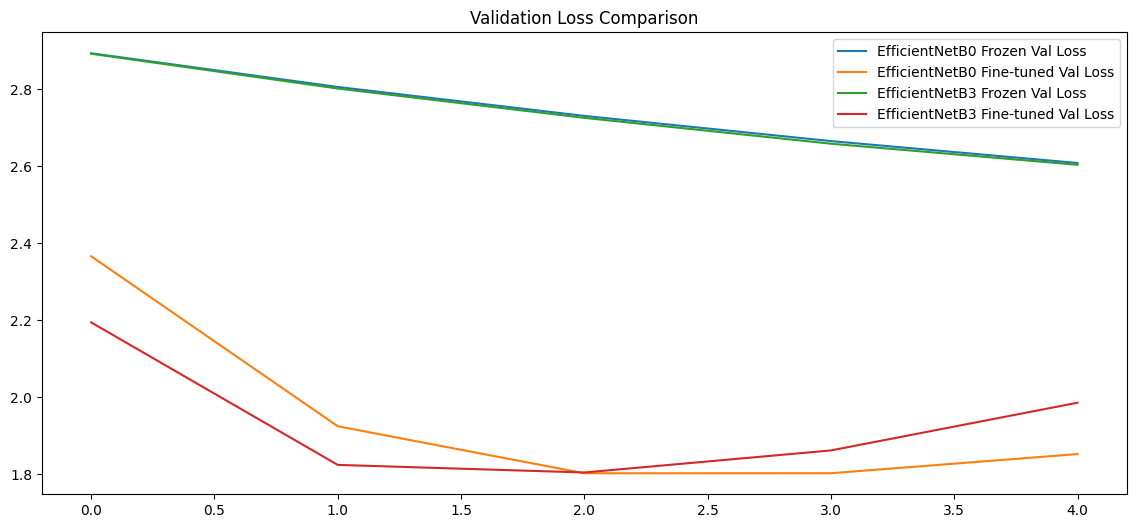

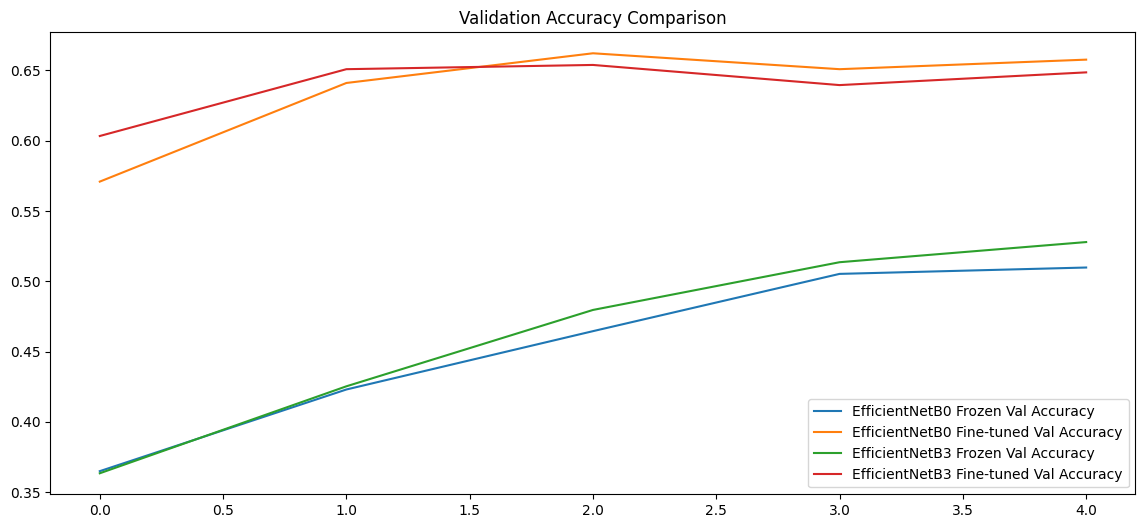

In [ ]:
#plot curves
def plot_curves(results):
    plt.figure(figsize=(14,6))
    for k,v in results.items():
        plt.plot(v['val_loss'], label=f"{k} Val Loss")
    plt.legend()
    plt.title("Validation Loss Comparison")
    plt.show()

    plt.figure(figsize=(14,6))
    for k,v in results.items():
        plt.plot(v['val_acc'], label=f"{k} Val Accuracy")
    plt.legend()
    plt.title("Validation Accuracy Comparison")
    plt.show()

plot_curves(results)

In [ ]:
import matplotlib.pyplot as plt
import torch

def show_predictions(model, val_loader, room_mapping, style_mapping, num_images=4):
    device = next(model.parameters()).device
    model.eval()
    room_inv = {v: k for k, v in room_mapping.items()}
    style_inv = {v: k for k, v in style_mapping.items()}
    imgs, room_labels, style_labels = next(iter(val_loader))
    imgs_dev = imgs.to(device)
    with torch.no_grad():
        room_out, style_out = model(imgs_dev)
    room_preds = room_out.argmax(1).cpu().numpy()
    style_preds = style_out.argmax(1).cpu().numpy()
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(min(num_images, len(imgs))):
        img = imgs[i].permute(1, 2, 0).numpy()
        img = (img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]).clip(0, 1)
        true_room = room_inv.get(room_labels[i].item(), '?')
        true_style = style_inv.get(style_labels[i].item(), '?')
        pred_room = room_inv.get(room_preds[i], '?')
        pred_style = style_inv.get(style_preds[i], '?')
        ax = axes[i] if num_images > 1 else axes
        ax.imshow(img)
        ax.set_title(f'True: {true_room} / {true_style}\nPred: {pred_room} / {pred_style}', fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


EfficientNetB0 Frozen loaded successfully.
EfficientNetB0 Fine-tuned loaded successfully.


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name tf_efficientnet_b3_ns to current tf_efficientnet_b3.ns_jft_in1k.
  model = create_fn(


EfficientNetB3 Frozen loaded successfully.
EfficientNetB3 Fine-tuned loaded successfully.

=== Predictions: EfficientNetB0 Frozen ===


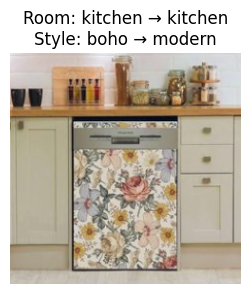

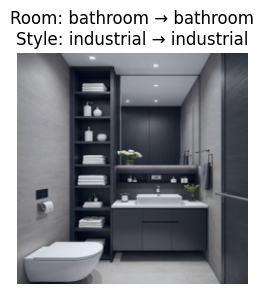

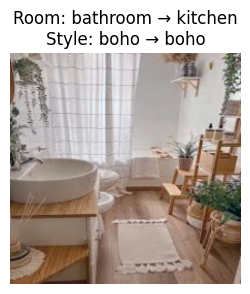

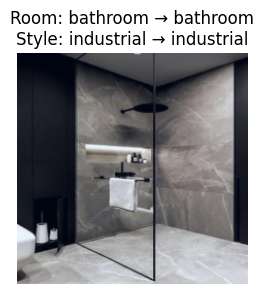


=== Predictions: EfficientNetB0 Fine-tuned ===


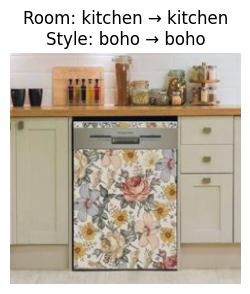

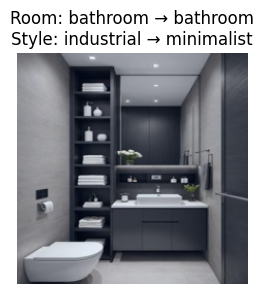

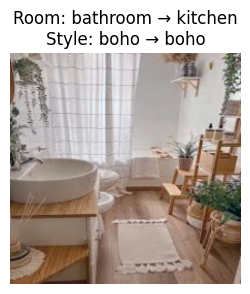

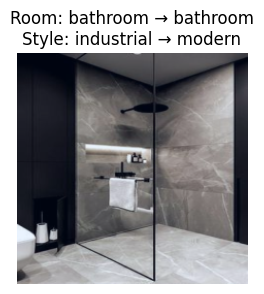


=== Predictions: EfficientNetB3 Frozen ===


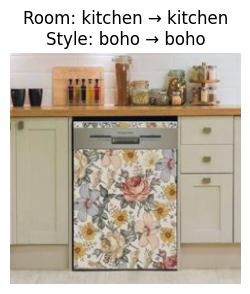

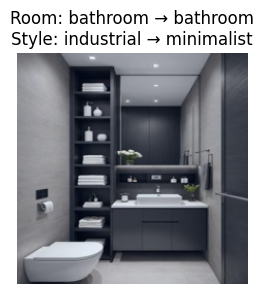

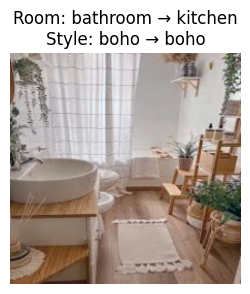

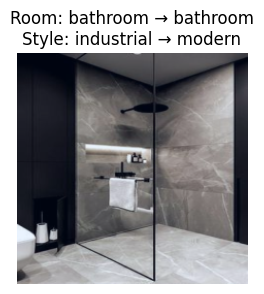


=== Predictions: EfficientNetB3 Fine-tuned ===


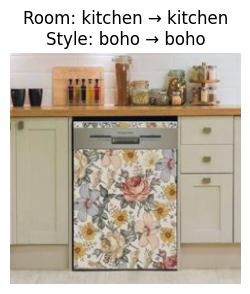

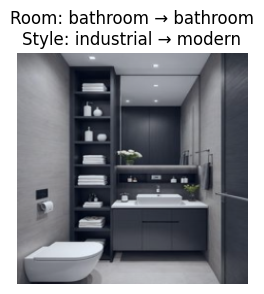

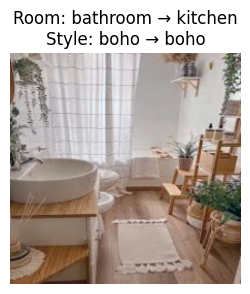

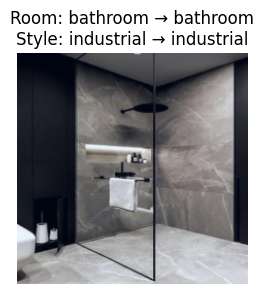

In [ ]:
# --- Load all saved models ---
trained_models = {}

model_infos = [
    ("EfficientNetB0 Frozen", "tf_efficientnet_b0_ns", True, "efficientnetb0_frozen.pth"),
    ("EfficientNetB0 Fine-tuned", "tf_efficientnet_b0_ns", False, "efficientnetb0_fine-tuned.pth"),
    ("EfficientNetB3 Frozen", "tf_efficientnet_b3_ns", True, "efficientnetb3_frozen.pth"),
    ("EfficientNetB3 Fine-tuned", "tf_efficientnet_b3_ns", False, "efficientnetb3_fine-tuned.pth")
]

for name, arch, freeze, path in model_infos:
    model = MultiTaskEfficientNet(
        arch,
        freeze=freeze,
        num_room_classes=num_room_classes,
        num_style_classes=num_style_classes
    )
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    trained_models[name] = model
    print(f"{name} loaded successfully.")

# --- Show predictions for all models ---
for name, model in trained_models.items():
    print(f"\n=== Predictions: {name} ===")
    show_predictions(model, val_loader, room_mapping, style_mapping, num_images=4)

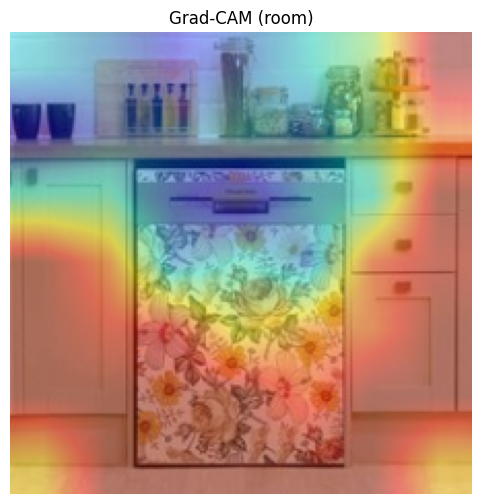

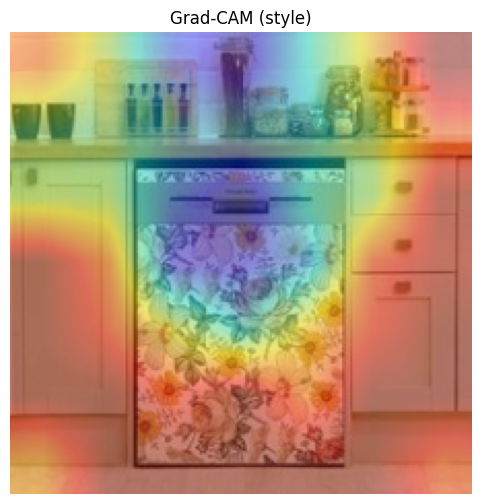

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        # Hook to capture activations and retain gradients
        def forward_hook(module, input, output):
            self.activations = output
            self.activations.retain_grad()  # important!
        self.target_layer.register_forward_hook(forward_hook)

    def __call__(self, x, class_idx, task='room'):
        self.model.zero_grad()
        x = x.requires_grad_()
        room_out, style_out = self.model(x)

        target = room_out[:, class_idx] if task=='room' else style_out[:, class_idx]
        target.backward(retain_graph=True)

        # Grad-CAM computation
        pooled_grads = torch.mean(self.activations.grad, dim=[0,2,3])
        activations = self.activations[0].cpu().detach()
        for i in range(activations.shape[0]):
            activations[i] *= pooled_grads[i].cpu()

        heatmap = torch.sum(activations, dim=0).numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= heatmap.max() + 1e-6
        return heatmap

def show_gradcam(model, dataset, idx=0, task='room'):
    model.to(device)
    model.eval()
    img, room_label, style_label = dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)

    # Get last conv layer
    target_layer = model.backbone.conv_head

    gradcam = GradCAM(model, target_layer)
    class_idx = room_label if task=='room' else style_label
    heatmap = gradcam(input_tensor, class_idx=class_idx, task=task)

    # Convert image to numpy
    img_np = img.permute(1,2,0).cpu().numpy()
    img_np = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img_np = np.clip(img_np,0,1)

    heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(np.uint8(img_np*255), 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(6,6))
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM ({task})")
    plt.axis('off')
    plt.show()

# --- Example ---
show_gradcam(trained_models['EfficientNetB3 Fine-tuned'], val_dataset, idx=0, task='room')
show_gradcam(trained_models['EfficientNetB3 Fine-tuned'], val_dataset, idx=0, task='style')
